# Phase 4 — Tabular Preprocessing

Scale numeric campaign fields and one-hot encode categoricals, using the **same train/test IDs** as the TF-IDF matrices so fusion stays aligned.

In [1]:
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path("..").resolve()
DATA_PATH = ROOT / "data" / "interim" / "ks_text_cleaned.csv"
SPLIT_PATH = ROOT / "data" / "processed" / "split_ids.csv"
OUT_DIR = ROOT / "data" / "processed"
FIG_DIR = ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

NUM_COLS = ["usd_goal_real", "duration_days"]
CAT_COLS = ["category", "main_category", "currency", "country"]

## 1. Load data and restore the Phase-3 split order

In [2]:
df = pd.read_csv(DATA_PATH)
split = pd.read_csv(SPLIT_PATH)

train_ids = split.loc[split["split"] == "train", "ID"]
test_ids = split.loc[split["split"] == "test", "ID"]

train_df = train_ids.to_frame().merge(df, on="ID", how="left")
test_df = test_ids.to_frame().merge(df, on="ID", how="left")

assert len(train_df) == len(train_ids)
assert len(test_df) == len(test_ids)
assert train_df["ID"].tolist() == train_ids.tolist()
assert train_df["target"].isna().sum() == 0

y_train = np.load(OUT_DIR / "y_train.npy")
y_test = np.load(OUT_DIR / "y_test.npy")
assert np.array_equal(train_df["target"].to_numpy(), y_train)
assert np.array_equal(test_df["target"].to_numpy(), y_test)

print(f"train: {train_df.shape} | test: {test_df.shape}")
train_df[NUM_COLS + CAT_COLS + ["target"]].head()

train: (264728, 16) | test: (66183, 16)


,usd_goal_real,duration_days,category,main_category,currency,country,target
0,2500.00,14.219144,Product Design,Design,USD,US,1
1,10000.00,29.055764,Documentary,Film & Video,USD,US,0
2,3200.00,27.208437,Country & Folk,Music,USD,US,1
3,300.00,24.178380,Crafts,Crafts,USD,US,1
4,2746.17,13.087662,Children's Books,Publishing,AUD,AU,1


### What this alignment shows

Row order matches the TF-IDF matrices and saved targets. If IDs or labels diverged here, fusion would silently mix campaigns — these asserts catch that early.

## 2. Build the tabular transformer

- Numeric → `StandardScaler` (fit on train only)
- Categorical → `OneHotEncoder(handle_unknown="ignore")` so unseen test levels become all zeros

In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUM_COLS),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=True),
            CAT_COLS,
        ),
    ],
    remainder="drop",
    sparse_threshold=0.3,
)

X_tab_train = preprocessor.fit_transform(train_df[NUM_COLS + CAT_COLS])
X_tab_test = preprocessor.transform(test_df[NUM_COLS + CAT_COLS])

if not sparse.issparse(X_tab_train):
    X_tab_train = sparse.csr_matrix(X_tab_train)
if not sparse.issparse(X_tab_test):
    X_tab_test = sparse.csr_matrix(X_tab_test)

feature_names = np.array(preprocessor.get_feature_names_out())

print(f"X_tab_train: {X_tab_train.shape} | nnz density: {X_tab_train.nnz / np.prod(X_tab_train.shape):.4f}")
print(f"X_tab_test:  {X_tab_test.shape} | nnz density: {X_tab_test.nnz / np.prod(X_tab_test.shape):.4f}")
print(f"features: {len(feature_names)} (2 scaled + {len(feature_names) - 2} one-hot)")

X_tab_train: (264728, 213) | nnz density: 0.0282
X_tab_test:  (66183, 213) | nnz density: 0.0282
features: 213 (2 scaled + 211 one-hot)


### What this matrix shows

Tabular width is much smaller than TF-IDF (hundreds of columns vs 2,500), but denser because each row activates several category flags plus two scaled numerics. That contrast is the reason Phase 5 studies sparse vs dense layouts before fusion.

## 3. Quick sanity checks on scaled numerics

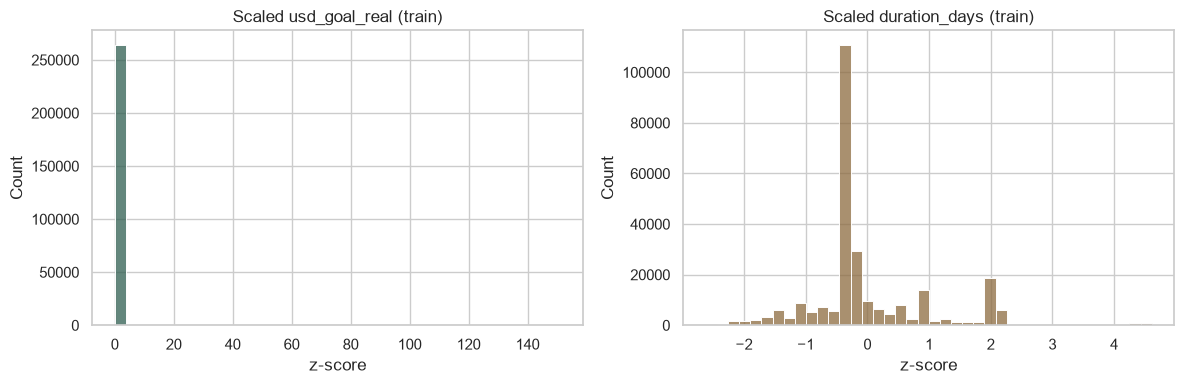

,usd_goal_real,duration_days
mean,0.000,0.000
std,1.000,1.000
min,-0.037,-2.623
max,151.220,4.610


In [4]:
scaler = preprocessor.named_transformers_["num"]
scaled_train = scaler.transform(train_df[NUM_COLS])
scaled_stats = pd.DataFrame(
    scaled_train,
    columns=NUM_COLS,
).agg(["mean", "std", "min", "max"]).round(3)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color in zip(axes, NUM_COLS, ["#2f5d50", "#8c6b3f"]):
    sns.histplot(scaled_train[:, NUM_COLS.index(col)], bins=40, ax=ax, color=color)
    ax.set_title(f"Scaled {col} (train)")
    ax.set_xlabel("z-score")
plt.tight_layout()
fig.savefig(FIG_DIR / "04_scaled_numeric_distributions.png", dpi=150)
plt.show()

scaled_stats

### What this figure shows

After `StandardScaler`, train means are ~0 and stds ~1. Goals stay skewed even after scaling (expected for money), but magnitudes are now comparable to one-hot and TF-IDF-style inputs for linear models.

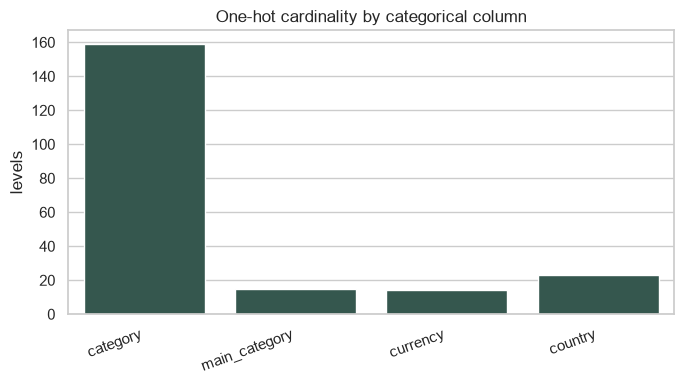

,column,n_levels
0,category,159
1,main_category,15
2,currency,14
3,country,23


In [5]:
ohe = preprocessor.named_transformers_["cat"]
n_levels = {col: len(levels) for col, levels in zip(CAT_COLS, ohe.categories_)}
level_table = pd.DataFrame(
    {"column": list(n_levels.keys()), "n_levels": list(n_levels.values())}
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=level_table, x="column", y="n_levels", color="#2f5d50", ax=ax)
ax.set_title("One-hot cardinality by categorical column")
ax.set_xlabel("")
ax.set_ylabel("levels")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
fig.savefig(FIG_DIR / "04_categorical_cardinality.png", dpi=150)
plt.show()

level_table

### What this figure shows

`category` dominates width (many fine-grained Kickstarter niches). `main_category`, `currency`, and `country` add fewer columns but still carry useful structure for the tabular branch.

## 4. Save tabular artifacts

In [6]:
sparse.save_npz(OUT_DIR / "X_tab_train.npz", X_tab_train.tocsr())
sparse.save_npz(OUT_DIR / "X_tab_test.npz", X_tab_test.tocsr())
pd.DataFrame({"feature": feature_names}).to_csv(OUT_DIR / "tab_feature_names.csv", index=False)
joblib.dump(preprocessor, OUT_DIR / "tabular_preprocessor.joblib")

meta = {
    "numeric_cols": NUM_COLS,
    "categorical_cols": CAT_COLS,
    "n_train": int(X_tab_train.shape[0]),
    "n_test": int(X_tab_test.shape[0]),
    "n_features": int(X_tab_train.shape[1]),
    "n_numeric": len(NUM_COLS),
    "n_onehot": int(X_tab_train.shape[1] - len(NUM_COLS)),
    "train_density": float(X_tab_train.nnz / np.prod(X_tab_train.shape)),
    "test_density": float(X_tab_test.nnz / np.prod(X_tab_test.shape)),
    "aligned_with": "split_ids.csv + X_text_*.npz + y_*.npy",
}
with open(OUT_DIR / "tabular_meta.json", "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print("saved to", OUT_DIR)
meta

saved to /Users/koriginjasathvik/Desktop/ML_Summer_Project/data/processed


{'numeric_cols': ['usd_goal_real', 'duration_days'],
 'categorical_cols': ['category', 'main_category', 'currency', 'country'],
 'n_train': 264728,
 'n_test': 66183,
 'n_features': 213,
 'n_numeric': 2,
 'n_onehot': 211,
 'train_density': 0.028169014084507043,
 'test_density': 0.028169014084507043,
 'aligned_with': 'split_ids.csv + X_text_*.npz + y_*.npy'}

## Phase 4 takeaways

- Numeric fields scaled with `StandardScaler` (train fit only).
- Categoricals one-hot encoded with unknown-level handling for test.
- Row order locked to Phase 3 split IDs / labels.
- Outputs: `X_tab_train.npz`, `X_tab_test.npz`, `tabular_preprocessor.joblib`.
- Notes: [`docs/tabular.md`](../docs/tabular.md).